
# Assignment: Shadow-Invariant Vision with OpenCV and Kornia

## Motivation

A shadow can create a strong image boundary even though there is no corresponding boundary in scene geometry or material.

Before beginning, watch [a Tesla on FSD 14.2.2.5 swerve for a shadow](https://x.com/EliasMartinez/status/2034946481744929113), reported by Elias Martinez in March 2026. The driver disengaged.

The central question of this assignment is:

> Can we construct an image representation that responds strongly to changes in surface reflectance but weakly to changes caused only by illumination?

You will implement a shadow-invariant representation inspired by Chapter 10 of Peter Corke's *Robotics, Vision & Control*.

[Download Chapter 10, Light and Color (PDF, 40 pages)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)

Reference notebook:

https://github.com/petercorke/RVC3-python/blob/main/notebooks/chap10.ipynb

Focus on:

- §10.1 Spectral Representation of Light
- §10.2 Color
- §10.4 Application: Color Images
- §10.4.2 Shadow Removal

You will first implement the relevant computations with NumPy and OpenCV, then port the final shadow-invariant pipeline to PyTorch/Kornia.



## Learning Objectives

By the end of this assignment, you should be able to:

1. Explain why shadows alter image measurements without altering surface material.
2. Relate illumination spectra to measured color.
3. Compare RGB, HSV, and Lab for illuminated and shadowed regions.
4. Construct a log-chromaticity representation.
5. Compute a one-dimensional shadow-invariant image.
6. Quantitatively evaluate shadow suppression.
7. Port the final computation to a PyTorch/Kornia tensor pipeline.



# 1. Development Environment

Use the course development environment:

https://github.com/pantelis/eng-ai-agents

Open the repository in VS Code as a Dev Container.

Inside the container run:

```bash
make start
make install-notebooks
source .venv/bin/activate
```

`make start` alone installs only the base dependencies. `make install-notebooks` adds OpenCV, PyTorch and Kornia, which the sections below use.

GPU acceleration is not required for full credit.


In [2]:
!pip install kornia

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 103.3 MB/s eta 0:00:00


In [3]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch
import kornia
import time

print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("PyTorch:", torch.__version__)
print("Kornia:", kornia.__version__)
print("CUDA available:", torch.cuda.is_available())


OpenCV: 5.0.0
NumPy: 2.1.3
PyTorch: 2.11.0+cu128
Kornia: 0.8.3
CUDA available: True



# 2. Why Does a Shadow Change an Image?

A simplified image-formation model is

$$
I_k =
\int E(\lambda)R(\lambda)Q_k(\lambda)\,d\lambda,
$$

where

- $E(\lambda)$ is illumination,
- $R(\lambda)$ is surface reflectance,
- $Q_k(\lambda)$ is the spectral response of camera channel $k$.

The key observation is:

$$
\text{measured pixel value} \neq \text{surface reflectance alone}.
$$

Measured RGB depends on both the material and the illumination.

In a cast shadow, the material reflectance is approximately unchanged, but the illumination reaching the surface changes.



## 2.1 Blackbody Illumination

Implement Planck's law:

$$
B(\lambda,T)
=
\frac{2hc^2}{\lambda^5}
\frac{1}
{\exp\left(\frac{hc}{\lambda k_BT}\right)-1}.
$$

Plot normalized spectra for:

$$
T_1 = 2600\text{ K},
\qquad
T_2 = 5778\text{ K}.
$$

Answer briefly:

1. Why can the same material produce different RGB values under these two illuminants?
2. In a cast shadow, what changes: reflectance or illumination?


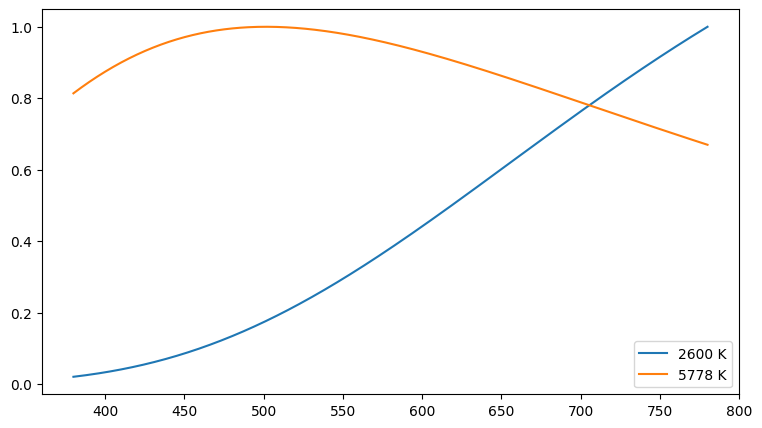

In [4]:
def blackbody(wavelength_m, temperature_k):
    h = 6.62607015e-34
    c = 299792458.0
    k_B = 1.380649e-23

    numerator = 2 * h * c**2
    exponent = (h*c) / (wavelength_m * k_B * temperature_k)
    denominator = wavelength_m**5 * (np.exp(exponent)-1)

    return numerator / denominator


wavelength_nm = np.linspace(380, 780, 400)
wavelength_m = wavelength_nm * 1e-9

lamp = blackbody(wavelength_m, 2600)
sun = blackbody(wavelength_m, 5778)

lamp = lamp/lamp.max()
sun = sun/sun.max()

plt.figure(figsize=(9,5))
plt.plot(wavelength_nm, lamp, label="2600 K")
plt.plot(wavelength_nm, sun, label="5778 K")
plt.legend()
plt.show()
# TODO: plot lamp and sun
# Normalize each curve and plot both.



### Short Answer

Write your response here.

- Same material, different illuminants:
<br>
The RGB values measured depend on both the illumination spectrum and surface reflectance. The same material can produce different measurements because a 5778K light source and a 2600K light source contain different amounts of energy at different wavelengths.

<br>

- What changes in a cast shadow:
The surface reflectance does not change, the illumination changes.



# 3. Observe a Shadow in Different Color Spaces

Use Corke's `parks.png` image or another supplied outdoor image containing a strong cast shadow.

Load the image with OpenCV and select two small regions of the same physical surface:

- one directly illuminated,
- one inside the shadow.

You will compare the regions in RGB, HSV, and Lab.


Image shape (H, W, C): (2448, 3264, 3)


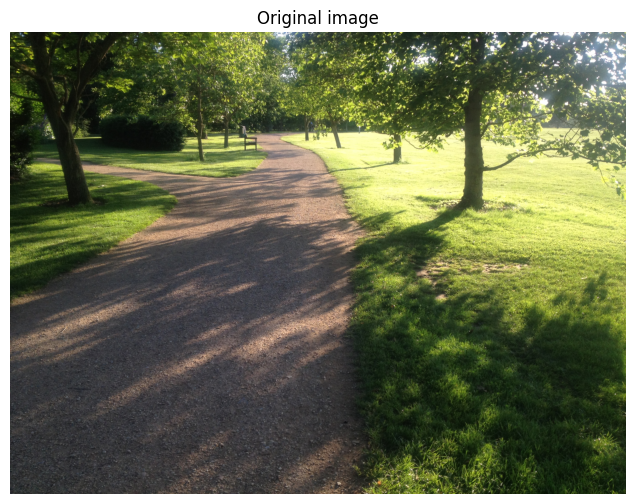

In [5]:

import os
import urllib.request

# parks.png is the outdoor scene Corke uses in chapter 10. It ships with the
# Machine Vision Toolbox data package (Peter Corke, MIT license).
IMAGE_URL = (
    "https://raw.githubusercontent.com/petercorke/machinevision-toolbox-python/"
    "main/packages/mvtb-data/mvtbdata/images/parks.png"
)
IMAGE_PATH = "parks.png"  # TODO: point this at your own image if you prefer

if not os.path.exists(IMAGE_PATH):
    urllib.request.urlretrieve(IMAGE_URL, IMAGE_PATH)

image_bgr = cv2.imread(IMAGE_PATH)
if image_bgr is None:
    raise FileNotFoundError(
        f"Could not load {IMAGE_PATH}. Check the path, or download the image "
        f"yourself from {IMAGE_URL}."
    )

print("Image shape (H, W, C):", image_bgr.shape)

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 6))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Original image")
plt.show()



## 3.1 Define Illuminated and Shadowed Regions

Choose two rectangular regions containing the same material.

Store them as:

```python
(x1, y1, x2, y2)
```

where `(x1, y1)` is the upper-left corner and `(x2, y2)` is the lower-right corner.


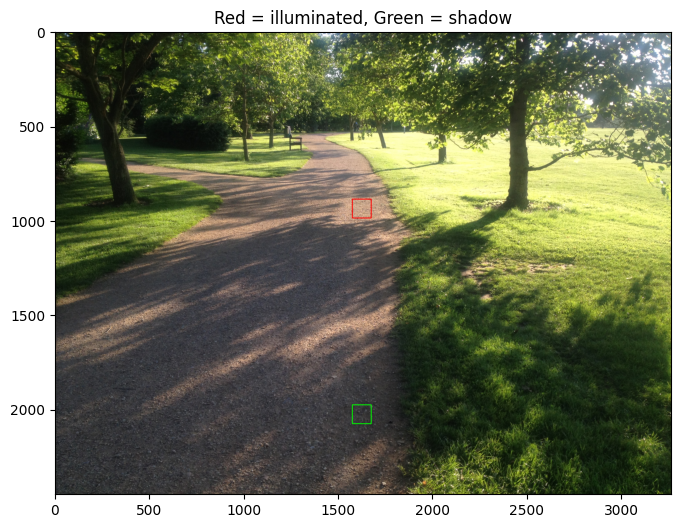

In [6]:

# TODO: replace with coordinates appropriate for your image.
lit_roi = (1575, 885, 1675, 985)
shadow_roi = (1575, 1975, 1675, 2075)

def crop_roi(image, roi):
    x1, y1, x2, y2 = roi
    return image[y1:y2, x1:x2]

def mean_color(image, roi):
    patch = crop_roi(image, roi)
    return patch.reshape(-1, patch.shape[-1]).mean(axis=0)

# TODO: visualize the chosen rectangles on the image.
display_image = image_rgb.copy()

x1, y1, x2, y2 = lit_roi
cv2.rectangle(
    display_image,
    (x1, y1),
    (x2, y2),
    (255, 0, 0),
    3
)

x1, y1, x2, y2 = shadow_roi
cv2.rectangle(
    display_image,
    (x1, y1),
    (x2, y2),
    (0, 255, 0),
    3
)

plt.figure(figsize=(10, 6))
plt.imshow(display_image)
plt.title("Red = illuminated, Green = shadow")
plt.axis("on")
plt.show()

In [7]:

hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)

rgb_lit = mean_color(image_rgb, lit_roi)
rgb_shadow = mean_color(image_rgb, shadow_roi)

hsv_lit = mean_color(hsv, lit_roi)
hsv_shadow = mean_color(hsv, shadow_roi)

lab_lit = mean_color(lab, lit_roi)
lab_shadow = mean_color(lab, shadow_roi)

print("RGB lit:    ", rgb_lit)
print("RGB shadow: ", rgb_shadow)
print("HSV lit:    ", hsv_lit)
print("HSV shadow: ", hsv_shadow)
print("Lab lit:    ", lab_lit)
print("Lab shadow: ", lab_shadow)


RGB lit:     [201.2404 164.2421 137.2771]
RGB shadow:  [55.4383 54.9101 56.6739]
HSV lit:     [ 12.666   82.2863 201.2404]
HSV shadow:  [106.2987   9.7752  56.9149]
Lab lit:     [178.6251 137.7589 147.1675]
Lab shadow:  [ 58.8711 128.8297 127.0408]



### Questions

1. Which components change most strongly across the shadow?

In RGB, all three components changes strongly. In HSV, the V component changes from 201 to 57, saturation and hue change a good amount too, due to the low saturation. In Lab, the L (lightness) component changes the most strongly.

2. Does converting to HSV or Lab completely remove the shadow?

No, but they do help seperate color information and brightness.

3. Why is separating intensity from chromatic information useful?

It's useful because shadows mainly cause a large change in brightness/illumination, while the material itself remains the same. By seperating the information, a vision model can have an easier time recognizing that a surface with both a shadowed region and an illuminated region is one single surface.


# 4. Implement the Shadow-Invariant Image

This is the main part of the assignment.

Do not use Corke's `shadow_invariant()` function.

You will implement:

1. sRGB linearization
2. log chromaticity
3. 2-D projection
4. a 1-D invariant image



## 4.1 Convert sRGB to Linear RGB

Convert the image to floating-point RGB in $[0,1]$.

Implement the inverse sRGB transfer function:

$$
C_{\text{linear}}
=
\begin{cases}
C_{\text{sRGB}}/12.92,
&
C_{\text{sRGB}}\leq0.04045
\\[4pt]
\left(
\frac{C_{\text{sRGB}}+0.055}{1.055}
\right)^{2.4},
&
\text{otherwise}.
\end{cases}
$$


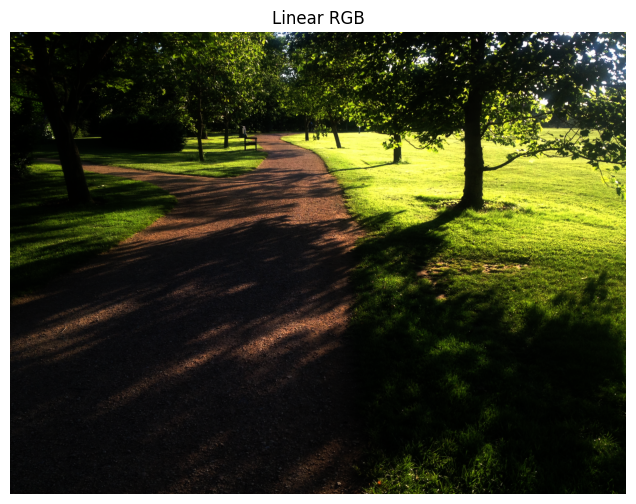

In [8]:

def srgb_to_linear(rgb):
    # rgb must be float32/float64 in [0, 1]
    # TODO: implement the inverse sRGB transfer function.
    linear = np.where(
        rgb <= 0.04045,
        rgb / 12.92,
        ((rgb + 0.055) / 1.055) ** 2.4
    )

    return linear

rgb = image_rgb.astype(np.float32) / 255.0
linear_rgb = srgb_to_linear(rgb)

# TODO: display linear_rgb after clipping to [0,1].
plt.figure(figsize=(10, 6))
plt.imshow(np.clip(linear_rgb, 0, 1))
plt.title("Linear RGB")
plt.axis("off")
plt.show()


## 4.2 Log Chromaticity

For each pixel compute the geometric mean

$$
M=(RGB)^{1/3}.
$$

Then define

$$
\rho_R=\log\frac{R}{M},
\qquad
\rho_G=\log\frac{G}{M},
\qquad
\rho_B=\log\frac{B}{M}.
$$

Use a small $\epsilon$ for numerical stability.

Verify numerically that

$$
\rho_R+\rho_G+\rho_B\approx0.
$$


In [9]:

def log_chromaticity(linear_rgb, eps=1e-6):
    # TODO:
    # 1. clamp values with eps
    safe_rgb = np.clip(linear_rgb, eps, None)
    # 2. compute geometric mean M
    R = safe_rgb[..., 0]
    G = safe_rgb[..., 1]
    B = safe_rgb[..., 2]
    M = np.cbrt(R * G * B)
    # 3. compute rho_R, rho_G, rho_B
    rho_R = np.log(R / M)
    rho_G = np.log(G / M)
    rho_B = np.log(B / M)
    # 4. stack into an H x W x 3 array
    rho = np.stack(
      [rho_R, rho_G, rho_B],
      axis=-1
    )
    return rho

rho = log_chromaticity(linear_rgb)

# TODO: verify rho[...,0] + rho[...,1] + rho[...,2] is approximately zero.
rho_sum = rho[..., 0] + rho[..., 1] + rho[..., 2]

print("Mean absolute sum:", np.mean(np.abs(rho_sum)))

Mean absolute sum: 1.1561721e-07



## 4.3 Project to a Two-Dimensional Chromaticity Plane

Use the orthonormal basis

$$
u_1=
\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
-1\\
0
\end{bmatrix},
\qquad
u_2=
\frac{1}{\sqrt{6}}
\begin{bmatrix}
1\\
1\\
-2
\end{bmatrix}.
$$

Compute

$$
\chi_1=u_1^T\rho,
\qquad
\chi_2=u_2^T\rho.
$$


In [10]:

u1 = np.array([1.0, -1.0, 0.0]) / np.sqrt(2.0)
u2 = np.array([1.0, 1.0, -2.0]) / np.sqrt(6.0)

# TODO: compute chi1 and chi2 for all pixels.
chi1 = np.sum(rho * u1, axis=-1)
chi2 = np.sum(rho * u2, axis=-1)



## 4.4 Plot Illuminated and Shadowed Pixels in Log-Chromaticity Space

Plot pixels from the two selected ROIs in $(\chi_1,\chi_2)$ coordinates.

Use different markers or colors for the illuminated and shadowed regions.

Do the two groups appear displaced primarily along a common direction?


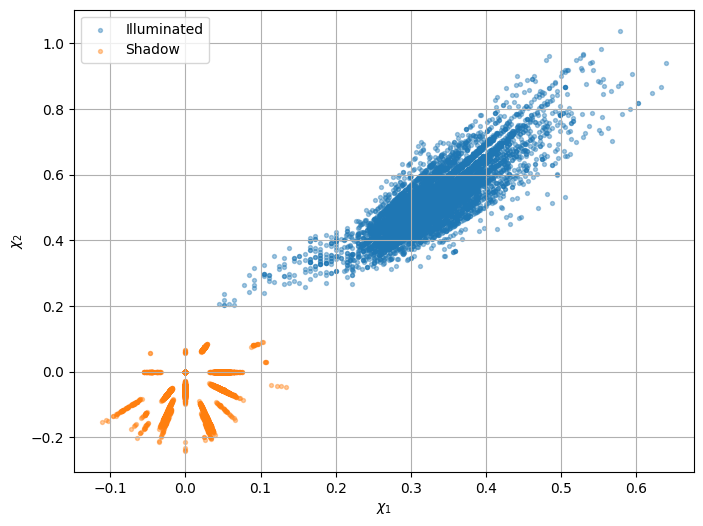

In [11]:

def roi_values(image_2d, roi):
    x1, y1, x2, y2 = roi
    return image_2d[y1:y2, x1:x2].ravel()

# TODO:
lit_x = roi_values(chi1, lit_roi)
lit_y = roi_values(chi2, lit_roi)
shadow_x = roi_values(chi1, shadow_roi)
shadow_y = roi_values(chi2, shadow_roi)
#
plt.figure(figsize=(8, 6))

plt.scatter(
    lit_x,
    lit_y,
    s=8,
    alpha=0.4,
    label="Illuminated"
)

plt.scatter(
    shadow_x,
    shadow_y,
    s=8,
    alpha=0.4,
    label="Shadow"
)

plt.xlabel(r"$\chi_1$")
plt.ylabel(r"$\chi_2$")

plt.legend()
plt.grid()

plt.show()


Yes, the groups appear displaced primarily in a common direction


## 4.5 Shadow-Invariant Projection

Reproduce Corke's fixed-angle example using

$$
\theta=0.7\text{ rad}.
$$

Compute

$$
I_{\text{inv}}
=
\chi_1\cos\theta
+
\chi_2\sin\theta.
$$

Normalize only for visualization.


In [12]:

theta = 0.7

# TODO:
invariant = chi1 * np.cos(theta) + chi2 * np.sin(theta)

# Normalize for display only:
invariant_display = cv2.normalize(
    invariant, None, 0, 255, cv2.NORM_MINMAX
).astype(np.uint8)


Optional Section, we're going to sweep through theta to find the best value.

In [31]:
thetas = np.linspace(0, np.pi, 181)

deltas = []

for theta_test in thetas:
    invariant_test = (
        chi1 * np.cos(theta_test)
        + chi2 * np.sin(theta_test)
    )

    lit_mean = roi_values(invariant_test, lit_roi).mean()
    shadow_mean = roi_values(invariant_test, shadow_roi).mean()

    delta = abs(lit_mean - shadow_mean)
    deltas.append(delta)

deltas = np.array(deltas)

best_index = np.argmin(deltas)
best_theta = thetas[best_index]
best_delta = deltas[best_index]

print("Best theta:", best_theta)
print("Minimum ROI difference:", best_delta)

Best theta: 2.6354471705114375
Minimum ROI difference: 0.002213309088019068


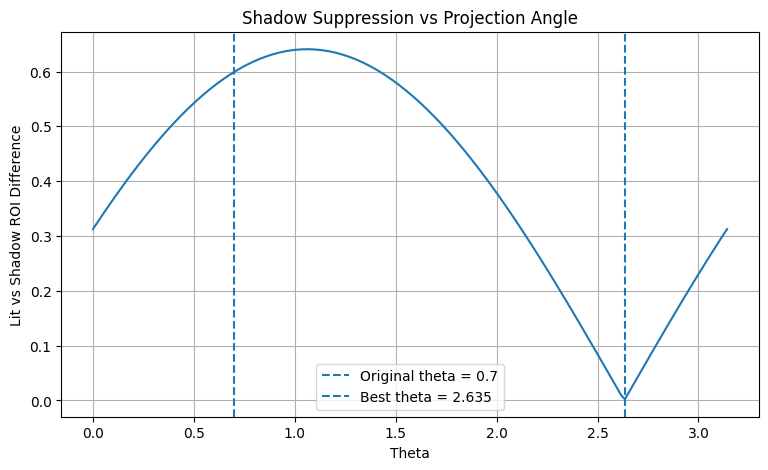

In [32]:
plt.figure(figsize=(9, 5))

plt.plot(thetas, deltas)

plt.axvline(
    0.7,
    linestyle="--",
    label="Original theta = 0.7"
)

plt.axvline(
    best_theta,
    linestyle="--",
    label=f"Best theta = {best_theta:.3f}"
)

plt.xlabel("Theta")
plt.ylabel("Lit vs Shadow ROI Difference")
plt.title("Shadow Suppression vs Projection Angle")
plt.legend()
plt.grid()

plt.show()

In [22]:
invariant_best = (
    chi1 * np.cos(best_theta)
    + chi2 * np.sin(best_theta)
)

invariant_best_display = cv2.normalize(
    invariant_best,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)


Display side-by-side:

1. original RGB image,
2. ordinary grayscale image,
3. shadow-invariant image.

Then answer:

1. Which shadow boundaries became weaker?
2. Which physical or material boundaries remained?


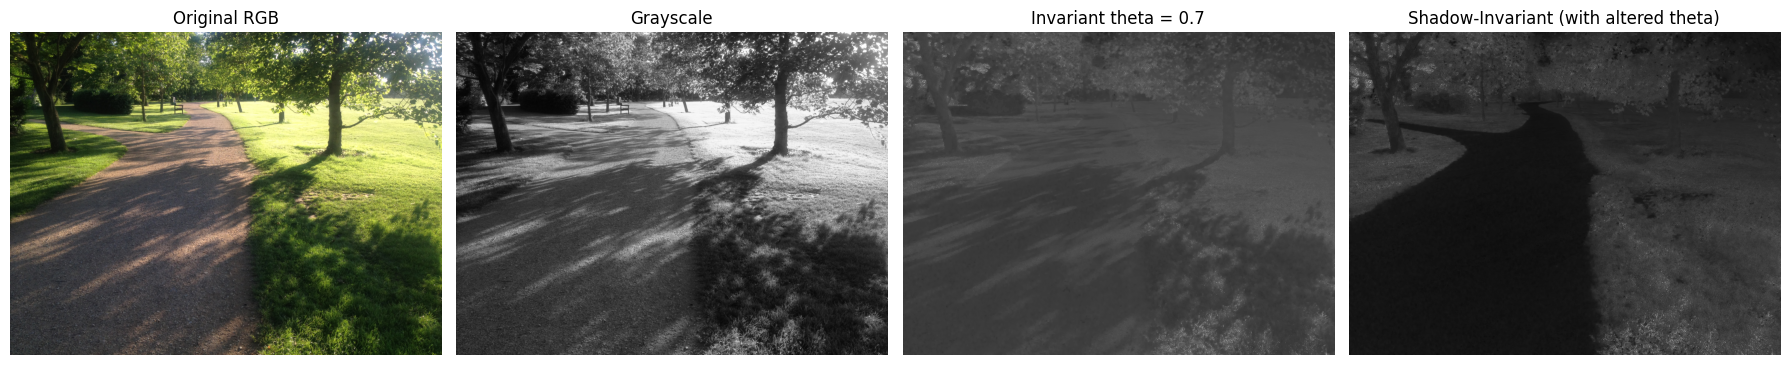

In [ ]:

gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

# TODO: create a 1x3 figure showing:
plt.figure(figsize=(18, 6))

# Original RGB
plt.subplot(1, 4, 1)
plt.imshow(image_rgb)
plt.title("Original RGB")
plt.axis("off")

# Ordinary grayscale
plt.subplot(1, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

# Shadow-invariant with theta = 0.7
plt.subplot(1, 4, 3)
plt.imshow(invariant_display, cmap="gray")
plt.title("Invariant theta = 0.7")
plt.axis("off")

# Shadow-invariant with altered theta
plt.subplot(1, 4, 4)
plt.imshow(invariant_best_display, cmap="gray")
plt.title("Shadow-Invariant (with altered theta)")
plt.axis("off")

plt.tight_layout()
plt.show()


1. The boundaries of the shadows coming off the trees became much weaker in the shadow-invariant image

2. In the shadow-invariant image the edges/boundaries of the tree trunks and the grass remain visible.


# 5. Quantitative Evaluation

Use the same illuminated and shadowed ROIs.

For grayscale compute

$$
\Delta_{\text{gray}}
=
|\mu_{\text{lit}}-\mu_{\text{shadow}}|.
$$

For the invariant image compute

$$
\Delta_{\text{inv}}
=
|\mu_{\text{lit}}^{\text{inv}}
-
\mu_{\text{shadow}}^{\text{inv}}|.
$$

A successful representation should approximately satisfy

$$
\Delta_{\text{inv}} < \Delta_{\text{gray}}.
$$


In [15]:

def mean_scalar(image_2d, roi):
    return roi_values(image_2d, roi).mean()

# TODO:
gray_lit_mean = mean_scalar(gray, lit_roi)
gray_shadow_mean = mean_scalar(gray, shadow_roi)
delta_gray = abs(gray_lit_mean - gray_shadow_mean)

inv_lit_mean = mean_scalar(invariant, lit_roi)
inv_shadow_mean = mean_scalar(invariant, shadow_roi)
delta_inv = abs(inv_lit_mean - inv_shadow_mean)

print("Grayscale lit mean:", gray_lit_mean)
print("Grayscale shadow mean:", gray_shadow_mean)
print("Delta gray:", delta_gray)

print()

print("Invariant lit mean:", inv_lit_mean)
print("Invariant shadow mean:", inv_shadow_mean)
print("Delta invariant:", delta_inv)

print()

print("These numbers are not really comparable so let's normalize the two")
delta_gray_norm = delta_gray / 255.0

invariant_range = invariant.max() - invariant.min()
delta_inv_norm = delta_inv / invariant_range

print("Normalized delta gray:", delta_gray_norm)
print("Normalized delta invariant:", delta_inv_norm)

Grayscale lit mean: 172.2176
Grayscale shadow mean: 55.2417
Delta gray: 116.9759

Invariant lit mean: 0.5823538018889959
Invariant shadow mean: -0.017036322718608853
Delta invariant: 0.5993901246076048

These numbers are not really comparable so let's normalize the two
Normalized delta gray: 0.4587290196078431
Normalized delta invariant: 0.06719177711821578



## 5.1 Compare Edges

Use OpenCV Canny on:

1. the ordinary grayscale image,
2. the normalized shadow-invariant image.

Look for one shadow edge and one real material/object edge.

The desired behavior is:

- weaker response at the shadow boundary,
- preservation of real scene boundaries.


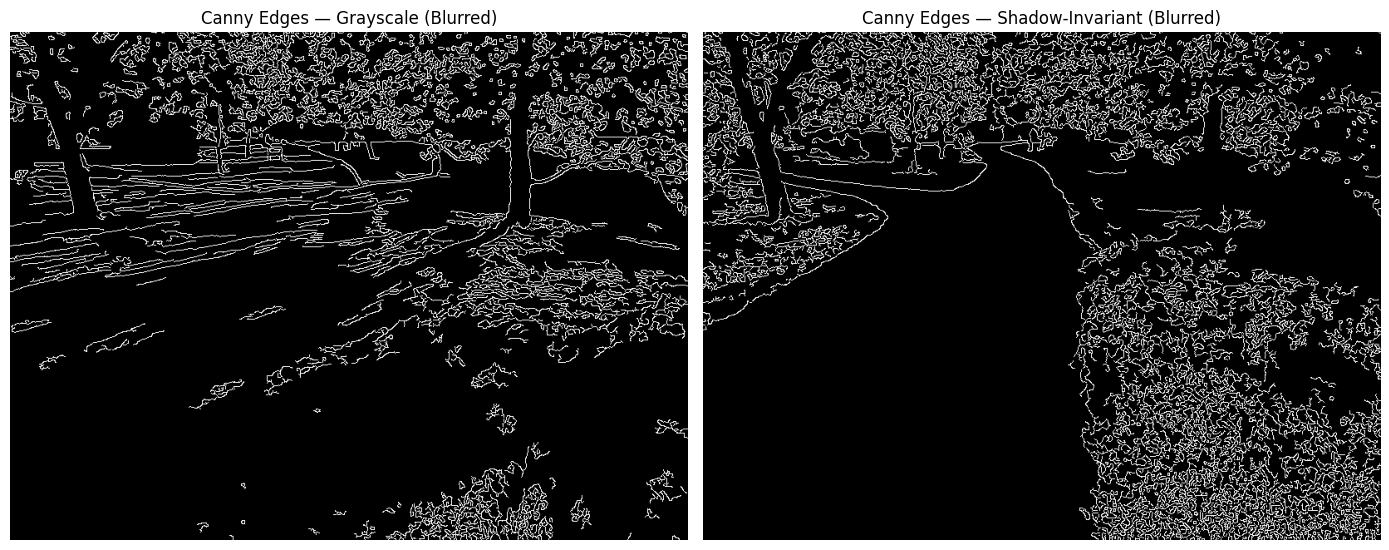

In [35]:

# TODO: tune thresholds if needed.
gray_small = cv2.resize(
    gray,
    None,
    fx=0.25,
    fy=0.25,
    interpolation=cv2.INTER_AREA
)

inv_small = cv2.resize(
    invariant_best_display,
    None,
    fx=0.25,
    fy=0.25,
    interpolation=cv2.INTER_AREA
)

gray_blur = cv2.GaussianBlur(gray_small, (5, 5), 0)
inv_blur = cv2.GaussianBlur(inv_small, (5, 5), 0)

edges_gray = cv2.Canny(gray_blur, 50, 150)

# TODO:
edges_inv = cv2.Canny(inv_blur, 10, 30)

# TODO: display both edge maps.
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(edges_gray, cmap="gray")
plt.title("Canny Edges — Grayscale (Blurred)")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(edges_inv, cmap="gray")
plt.title("Canny Edges — Shadow-Invariant (Blurred)")
plt.axis("off")

plt.tight_layout()
plt.show()



# 6. Port the Final Pipeline to PyTorch and Kornia

The goal of this section is to express the same classical computer-vision pipeline as tensor operations.

This allows:

- batching,
- GPU execution,
- automatic differentiation.

Kornia provides differentiable computer-vision operators that integrate directly with PyTorch computation graphs.


In [17]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

rgb_t = (
    torch.from_numpy(image_rgb)
    .permute(2, 0, 1)
    .unsqueeze(0)
    .float()
    .div(255.0)
    .to(device)
)

print("Tensor shape:", rgb_t.shape)
print("Device:", rgb_t.device)


Tensor shape: torch.Size([1, 3, 2448, 3264])
Device: cuda:0



## 6.1 Linear RGB with Kornia

Use:

```python
kornia.color.rgb_to_linear_rgb(...)
```

Then reproduce the same log-chromaticity and projection equations using PyTorch tensor operations.


In [18]:

linear_t = kornia.color.rgb_to_linear_rgb(rgb_t)

def shadow_invariant_torch(linear_rgb_t, theta=0.7, eps=1e-6):
    # Expected input shape: B x 3 x H x W
    #
    # TODO:
    # 1. clamp channels with eps
    safe_rgb = torch.clamp(linear_rgb_t, min=eps)

    # 2. compute geometric mean
    R = safe_rgb[:, 0]
    G = safe_rgb[:, 1]
    B = safe_rgb[:, 2]
    M = torch.pow(R * G * B, 1.0 / 3.0)

    # 3. compute log chromaticities
    rho_R = torch.log(R / M)
    rho_G = torch.log(G / M)
    rho_B = torch.log(B / M)
    rho = torch.stack([rho_R, rho_G, rho_B], dim=1)

    # 4. project using u1 and u2
    u1 = torch.tensor([1.0, -1.0, 0.0], dtype=rho.dtype, device=rho.device) / np.sqrt(2.0)

    u2 = torch.tensor([1.0, 1.0, -2.0], dtype=rho.dtype, device=rho.device) / np.sqrt(6.0)

    # 5. compute invariant = chi1*cos(theta) + chi2*sin(theta)
    chi1 = (rho * u1.view(1, 3, 1, 1)).sum(dim=1)
    chi2 = (rho * u2.view(1, 3, 1, 1)).sum(dim=1)

    # Return shape: B x H x W
    invariant = (chi1 * np.cos(theta) + chi2 * np.sin(theta))
    return invariant

invariant_t = shadow_invariant_torch(linear_t, theta=0.7)



## 6.2 Compare NumPy/OpenCV and PyTorch/Kornia Results

Compute

$$
\mathrm{MAE}
=
\frac{1}{N}
\sum_i
|I_i^{\mathrm{NumPy}}
-
I_i^{\mathrm{PyTorch}}|.
$$

The two implementations should be numerically very similar.


In [19]:

# TODO:
invariant_t_np = invariant_t.squeeze(0).detach().cpu().numpy()
mae = np.mean(np.abs(invariant - invariant_t_np))
print("MAE:", mae)


MAE: 8.473639500821197e-08



## 6.3 Optional GPU Batch Experiment

If CUDA is available, process a batch of 32 identical images.

Report:

- execution device,
- batch shape,
- elapsed time.

No GPU speedup is required for full credit.


In [20]:

if torch.cuda.is_available():
    batch = rgb_t.repeat(4, 1, 1, 1)
    batch_linear = kornia.color.rgb_to_linear_rgb(batch)

    torch.cuda.synchronize()
    t0 = time.perf_counter()

    # TODO:
    batch_inv = shadow_invariant_torch(batch_linear, theta=0.7)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    print("Batch shape:", batch.shape)
    print("Elapsed:", elapsed)
else:
    print("CUDA not available; GPU timing is optional.")


Batch shape: torch.Size([4, 3, 2448, 3264])
Elapsed: 0.03366310200001976



# 7. Discussion

Return to the autonomous-driving example at the beginning.

Answer in approximately one paragraph:

1. Why does the shadow generate strong image structure even though there is no new physical object?
2. What quantity does the invariant projection attempt to suppress?
3. Why can preserving reflectance-related edges while suppressing illumination edges help perception?
4. Why would this classical method still be insufficient by itself for autonomous driving?

Consider geometry, depth, semantics, temporal reasoning, learned representations, and sensor fusion.

Answer:

A shadow creates strong image structure because shadows cause a large change in meaasured pixel intensity. This happens even though the underlying surface is the same whether or not it is illuminated. The invariant projection tries to dull the variation caused by shadows while retaining the borders related to reflectance. This is important for perception because a vision model should be able to recognize real object edges while ignoring edges caused by lighting. This method is not enough by itself to be used for autonomous driving because autonomous driving needs to know more about its environment than what edges are shadows. For example, a real system needs to understand depth, geometry, motion, as well as combine information from multiple sensors that aren't just cameras.


# Deliverables

Your notebook must execute from beginning to end, and you must submit it with all outputs saved.

Required outputs:

- two blackbody curves,
- RGB/HSV/Lab comparison,
- log-chromaticity scatter plot,
- shadow-invariant image,
- quantitative shadow comparison,
- OpenCV edge comparison,
- PyTorch/Kornia implementation,
- short final discussion.

## Submitting

Follow the [assignment submission guide](https://aegean.ai/aiml-common/resources/environment/assignment-submission). Commit this notebook with all cell outputs saved, and submit the complete GitHub URL of its directory.

The per-component points are on the assignment page.



# References

1. Peter Corke, *Robotics, Vision & Control: Fundamental Algorithms in Python*, 3rd ed., Springer, Chapter 10. [Download the chapter (PDF)](https://artifacts.aegeanai.com/pdf/corke-rvc3/ch10-light-and-color.pdf)
2. G. D. Finlayson, S. D. Hordley, and M. S. Drew, "Removing Shadows from Images," ECCV, 2002.
3. G. D. Finlayson, M. S. Drew, and C. Lu, "Intrinsic Images by Entropy Minimization," ECCV, 2004.
4. G. D. Finlayson, S. D. Hordley, C. Lu, and M. S. Drew, "On the Removal of Shadows from Images," IEEE TPAMI, 2006.
5. Kornia documentation: https://kornia.readthedocs.io/
6. OpenCV documentation: https://docs.opencv.org/
